# Strategy A (Rung 1) — Results & Pre-Registered Acceptance Check

Single XGBoost TAA tilt over the 11 SPDR sector ETFs (log-tilt around an equal-weight
anchor under a `[2%, 18%]` band, monthly, no-trade band 0.02, 5 bps cost), evaluated on a
sealed expanding walk-forward (test years 2005–2025).

This notebook **orchestrates and reports only** — all logic lives in the tested `etf` package.
It runs Strategy A vs buy-and-hold SPY and equal-weight, audits for leakage, runs Monte-Carlo
luck tests, and evaluates the six pre-registered acceptance bars in `experiments/H_strategy_a.md`.
**The config is fixed in advance; bars are not relaxed retroactively.**


In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
warnings.filterwarnings('ignore')

from etf.strategy.constants import SECTOR_ETFS, SECTOR_INCEPTION, BENCHMARK, COST_BPS
from etf.data.ingest_prices import download_prices, to_month_end
from etf.data.ingest_macro import download_macro
from etf.data.build_panel import build_panel
from etf.features.build_features import assemble_features, FEATURE_COLS
from etf.strategy.strategy_a import run_strategy_a
from etf.strategy.allocate import project_to_simplex
from etf.utils.walkforward import expanding_walks
from etf.utils.benchmarks import equal_weight
from etf.utils.backtest import compute_strategy_metrics
from etf.utils.validation import (label_shuffle_sharpe, feature_timing_gain,
                                  block_bootstrap_ci, dirichlet_null, deflated_sharpe)

HERE = os.getcwd()
ROOT = os.path.dirname(HERE) if os.path.basename(HERE) == 'notebooks' else HERE
DATA = os.path.join(ROOT, 'data', 'processed'); os.makedirs(DATA, exist_ok=True)
CONFIG = json.load(open(os.path.join(ROOT, 'experiments', 'configs', 'strategy_a.json')))
SEED = 0
print('config:', CONFIG)


config: {'xgb_params': {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_lambda': 1.0, 'objective': 'reg:squarederror'}, 'tilt_scale': 0.5, 'max_weight': 0.18, 'min_weight': 0.02, 'no_trade_band': 0.02, 'cost_bps': 5.0, 'first_test_year': 2005, 'last_test_year': 2025}


## 1. Data load
Daily total-return ETF + SPY prices (yfinance) and FRED macro series, cached to
`data/processed/` so re-runs are offline. First run requires network.


In [2]:
pp, mp = os.path.join(DATA, 'prices.parquet'), os.path.join(DATA, 'macro.parquet')
if os.path.exists(pp) and os.path.exists(mp):
    daily = pd.read_parquet(pp); macro = pd.read_parquet(mp)
    print('loaded cache:', daily.shape, macro.shape)
else:
    daily = download_prices(SECTOR_ETFS + [BENCHMARK], start='1998-01-01')
    macro = download_macro(start='1998-01-01')
    daily.to_parquet(pp); macro.to_parquet(mp)
    print('downloaded:', daily.shape, macro.shape)
daily.index.name = 'date'
print('tickers:', list(daily.columns))
print('range :', daily.index.min().date(), '->', daily.index.max().date())


loaded cache: (7165, 12) (7433, 4)
tickers: ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY', 'XLRE', 'XLC', 'SPY']
range : 1998-01-02 -> 2026-06-29


## 2. Month-end panel + PIT features
Month-end resample -> expanding 9->11 sector panel with forward-return labels -> point-in-time
price features (momentum / vol / drawdown / relative strength) + macro. Cached to `features.parquet`.


In [3]:
fp = os.path.join(DATA, 'features.parquet')
month_end = to_month_end(daily)
spy_daily = daily[BENCHMARK]
panel = build_panel(month_end[SECTOR_ETFS], SECTOR_ETFS, SECTOR_INCEPTION)
if os.path.exists(fp):
    features = pd.read_parquet(fp); print('loaded features cache:', features.shape)
else:
    features = assemble_features(panel, daily[SECTOR_ETFS], spy_daily, macro)
    features.to_parquet(fp); print('built features:', features.shape)
by_year = features.assign(yr=features.date.dt.year).groupby('yr').ticker.nunique()
print('feature rows:', len(features), '| dates:', features.date.nunique())
print('sectors available per year (expanding 9 -> 11):')
print(by_year.to_string())


loaded features cache: (3062, 20)
feature rows: 3062 | dates: 318
sectors available per year (expanding 9 -> 11):
yr
1999     9
2000     9
2001     9
2002     9
2003     9
2004     9
2005     9
2006     9
2007     9
2008     9
2009     9
2010     9
2011     9
2012     9
2013     9
2014     9
2015     9
2016    10
2017    10
2018    10
2019    11
2020    11
2021    11
2022    11
2023    11
2024    11
2025    11
2026    11


## 3. Run Strategy A + benchmarks (net of 5 bps)
Strategy A and equal-weight realize next-month returns (`sum(w * fwd_ret_1m)`), so SPY is
built **forward-labeled** the same way and all three are aligned to A's test months for a
fair comparison. Strategy A and equal-weight are charged 5 bps on turnover; SPY buy-and-hold
has ~zero turnover.


In [4]:
walks = expanding_walks(CONFIG['first_test_year'], CONFIG['last_test_year'])
res = run_strategy_a(features, walks, CONFIG, seed=SEED)
A_gross, A_turn = res['returns'], res['turnover']

def net(r, t):
    return r - (COST_BPS / 1e4) * t
A_net = net(A_gross, A_turn)
idx = A_net.index

# forward-labeled SPY (d -> d+1 return), aligned to A's test months
spy_fwd = month_end[BENCHMARK].dropna().pct_change().shift(-1)
spy = spy_fwd.reindex(idx)
ew_ret, ew_turn = equal_weight(panel)
ew_g = ew_ret.reindex(idx); ew_t = ew_turn.reindex(idx).fillna(0.0); ew_net = net(ew_g, ew_t)
assert spy.notna().all() and ew_net.notna().all(), 'benchmark alignment produced NaNs'

m_spy = compute_strategy_metrics(spy)
m_ew  = compute_strategy_metrics(ew_g, turnover=ew_t, cost_bps=COST_BPS)
m_A   = compute_strategy_metrics(A_gross, turnover=A_turn, cost_bps=COST_BPS)
cols = ['ann_return','ann_vol','sharpe','sortino','max_drawdown','calmar','hit_rate','avg_turnover']
table = pd.DataFrame({'SPY (buy & hold)': m_spy, 'Equal-Weight (net)': m_ew,
                      'Strategy A (net)': m_A}).T[cols]
table.loc['SPY (buy & hold)', 'avg_turnover'] = 0.0

sharpe_SPY = m_spy['sharpe']; sharpe_A_net = m_A['sharpe']
mdd_SPY = m_spy['max_drawdown']; mdd_A = m_A['max_drawdown']
sharpe_A_gross = compute_strategy_metrics(A_gross)['sharpe']  # gross, for gross-vs-gross null tests
print(f'Test window {idx.min().date()} -> {idx.max().date()} ({len(idx)} months)')
display(table.round(4))


Test window 2005-01-31 -> 2025-12-31 (252 months)


,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,hit_rate,avg_turnover
SPY (buy & hold),0.1081,0.1479,0.7308,0.9803,-0.5078,0.2129,0.6706,0.0000
Equal-Weight (net),0.1018,0.1455,0.6996,0.9098,-0.4912,0.2072,0.6627,0.0015
Strategy A (net),0.1067,0.1492,0.7153,0.9076,-0.4955,0.2154,0.6627,0.3540


## 4. Equity curves (net, log scale)


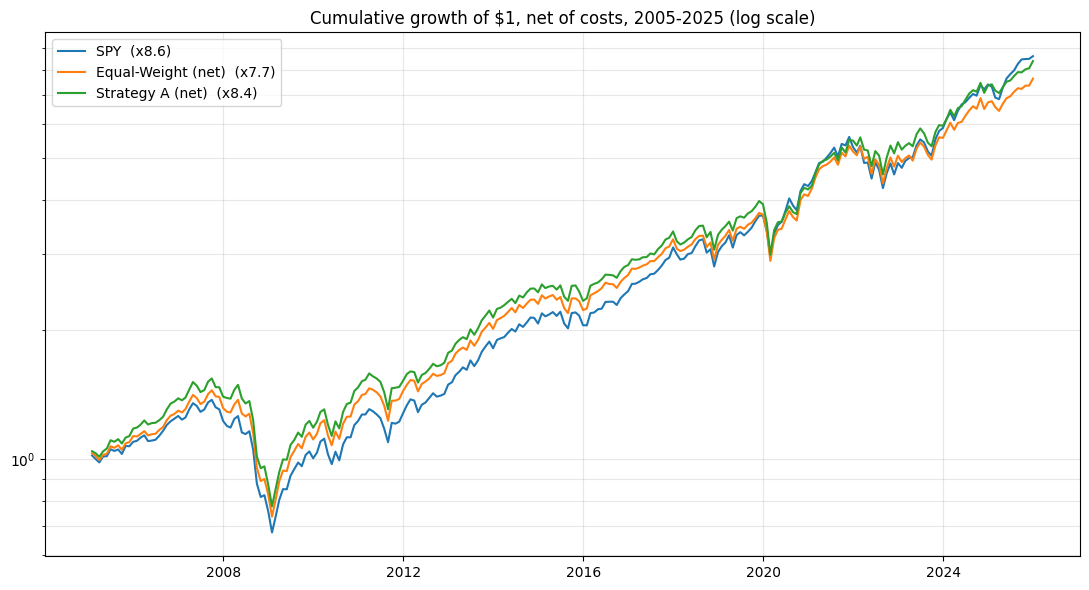

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
for name, r in [('SPY', spy), ('Equal-Weight (net)', ew_net), ('Strategy A (net)', A_net)]:
    eq = (1 + r).cumprod()
    ax.plot(eq.index, eq.values, label=f'{name}  (x{eq.iloc[-1]:.1f})')
ax.set_yscale('log'); ax.grid(True, which='both', alpha=0.3); ax.legend()
ax.set_title('Cumulative growth of $1, net of costs, 2005-2025 (log scale)')
plt.tight_layout(); plt.show()


## 5. Leakage audit
Two independent checks, both gross-vs-gross (cost is irrelevant to whether the signal is real).

**Label-shuffle (decisive):** retrain with `y_rank` permuted within each date. If the pipeline
leaked the label, real Sharpe would tower far above this null; a weak-but-clean signal sits just
above (even inside) it.

**Feature-timing (sensitivity, read with care):** leak each feature one month forward and re-run.
For **price-level** features (momentum, drawdown, relative strength) the forward-shifted value
mechanically contains next month's price — the numerator of the next-month return label — so a
positive gain is *expected* and merely confirms the model would exploit future prices if handed
them. It is **not** evidence of look-ahead in the point-in-time pipeline (skip-month momentum,
volatility, and macro features, whose forward shift does not overlap the label, stay near zero).
The label-shuffle test is the authority on leakage.


Sharpe(A) gross = 0.731
label-shuffle Sharpe: median=0.690, mean=0.693, 95th pct=0.738, max=0.757


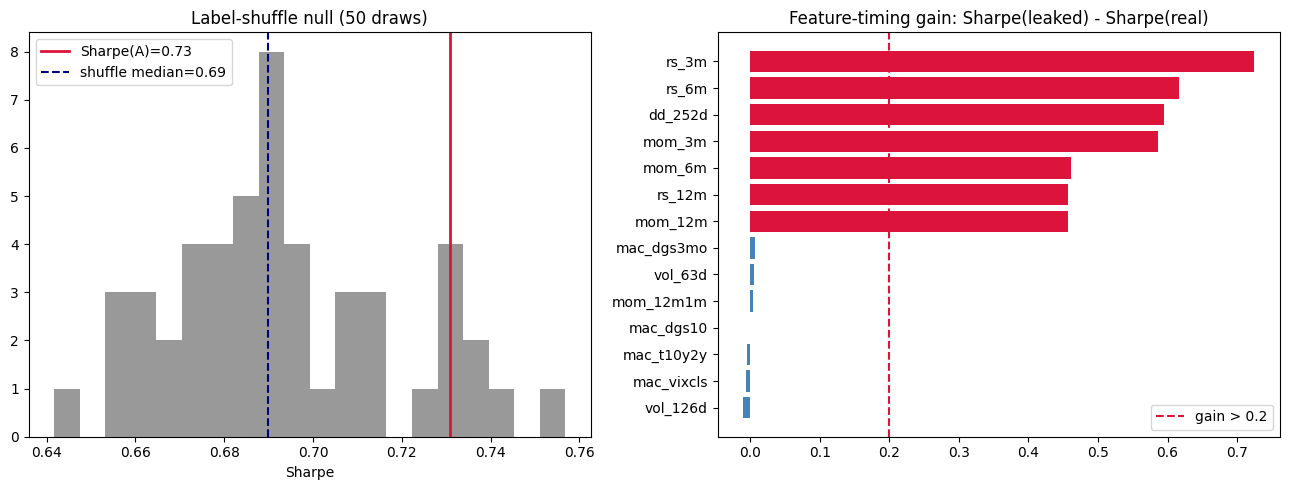

features whose 1-month-forward shift overlaps next-month return (gain>0.2, expected for price-level features, NOT a PIT leak): ['mom_3m', 'mom_6m', 'mom_12m', 'dd_252d', 'rs_3m', 'rs_6m', 'rs_12m']


In [6]:
N_SHUFFLES = 50
shuffled = label_shuffle_sharpe(features, walks, CONFIG, seed=SEED, n_shuffles=N_SHUFFLES)
print(f'Sharpe(A) gross = {sharpe_A_gross:.3f}')
print(f'label-shuffle Sharpe: median={np.median(shuffled):.3f}, mean={np.mean(shuffled):.3f}, '
      f'95th pct={np.percentile(shuffled,95):.3f}, max={np.max(shuffled):.3f}')

timing = {f: feature_timing_gain(features, walks, CONFIG, SEED, f) for f in FEATURE_COLS}
tg = pd.Series(timing).sort_values()
flagged = [f for f, v in timing.items() if v > 0.2]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].hist(shuffled, bins=20, color='gray', alpha=0.8)
ax[0].axvline(sharpe_A_gross, color='crimson', lw=2, label=f'Sharpe(A)={sharpe_A_gross:.2f}')
ax[0].axvline(np.median(shuffled), color='navy', ls='--', label=f'shuffle median={np.median(shuffled):.2f}')
ax[0].set_title(f'Label-shuffle null ({N_SHUFFLES} draws)'); ax[0].set_xlabel('Sharpe'); ax[0].legend()
ax[1].barh(tg.index, tg.values, color=['crimson' if v > 0.2 else 'steelblue' for v in tg.values])
ax[1].axvline(0.2, color='crimson', ls='--', label='gain > 0.2')
ax[1].set_title('Feature-timing gain: Sharpe(leaked) - Sharpe(real)'); ax[1].legend()
plt.tight_layout(); plt.show()
print('features whose 1-month-forward shift overlaps next-month return (gain>0.2,',
      'expected for price-level features, NOT a PIT leak):', flagged or 'none')


## 6. Monte-Carlo luck tests
**Seed stability** (net Sharpe across seeds 0-9), **block-bootstrap** 95% Sharpe CI on net A,
**Dirichlet random-weights null** (is allocation skill real?), and the **deflated Sharpe**
(multiple-testing correction; takes a per-period/monthly Sharpe).


In [7]:
SEEDS = list(range(10))
seed_rows = []
for s in SEEDS:
    rs = run_strategy_a(features, walks, CONFIG, seed=s)
    m = compute_strategy_metrics(net(rs['returns'], rs['turnover']))
    seed_rows.append({'seed': s, 'sharpe_net': m['sharpe'], 'ann_return': m['ann_return'],
                      'max_drawdown': m['max_drawdown']})
seed_df = pd.DataFrame(seed_rows)
print('seed stability (net):'); display(seed_df.round(4))
print(f'min net Sharpe across seeds = {seed_df.sharpe_net.min():.3f}')

ci = block_bootstrap_ci(A_net, n_boot=5000, mean_block=6, seed=SEED)
print('bootstrap 95% Sharpe CI (net A):', {k: round(v, 3) for k, v in ci.items()})

dn = dirichlet_null(features, walks, CONFIG, n_sims=2000, seed=SEED)
print('Dirichlet random-weights null:', {k: round(v, 4) for k, v in dn.items()})

monthly_sharpe = A_net.mean() / A_net.std(ddof=1)
n_obs = len(A_net)
dsr = deflated_sharpe(monthly_sharpe, n_trials=1, n_obs=n_obs)
print(f'\nmonthly Sharpe(A,net)={monthly_sharpe:.3f}, n_obs={n_obs}')
print(f'deflated Sharpe (n_trials=1, honest pre-registered single config) = {dsr:.4f}')
for nt in [5, 20, 50]:
    print(f'  sensitivity if n_trials={nt}: {deflated_sharpe(monthly_sharpe, nt, n_obs):.4f}')


seed stability (net):


,seed,sharpe_net,ann_return,max_drawdown
0,0,0.7153,0.1067,-0.4955
1,1,0.6887,0.1019,-0.5020
2,2,0.6929,0.1034,-0.4987
3,3,0.6970,0.1042,-0.5057
4,4,0.7123,0.1060,-0.4942
5,5,0.7177,0.1074,-0.4957
6,6,0.6977,0.1045,-0.4980
7,7,0.7034,0.1050,-0.4994
8,8,0.6922,0.1029,-0.4964
9,9,0.7109,0.1059,-0.4931


min net Sharpe across seeds = 0.689


bootstrap 95% Sharpe CI (net A): {'sharpe_point': 0.715, 'sharpe_lo': 0.197, 'sharpe_hi': 1.334}


Dirichlet random-weights null: {'strategy_sharpe': 0.7309, 'null_mean': 0.6967, 'p_value': 0.1405}

monthly Sharpe(A,net)=0.219, n_obs=252
deflated Sharpe (n_trials=1, honest pre-registered single config) = 0.9997
  sensitivity if n_trials=5: 0.9978
  sensitivity if n_trials=20: 0.9752
  sensitivity if n_trials=50: 0.9376


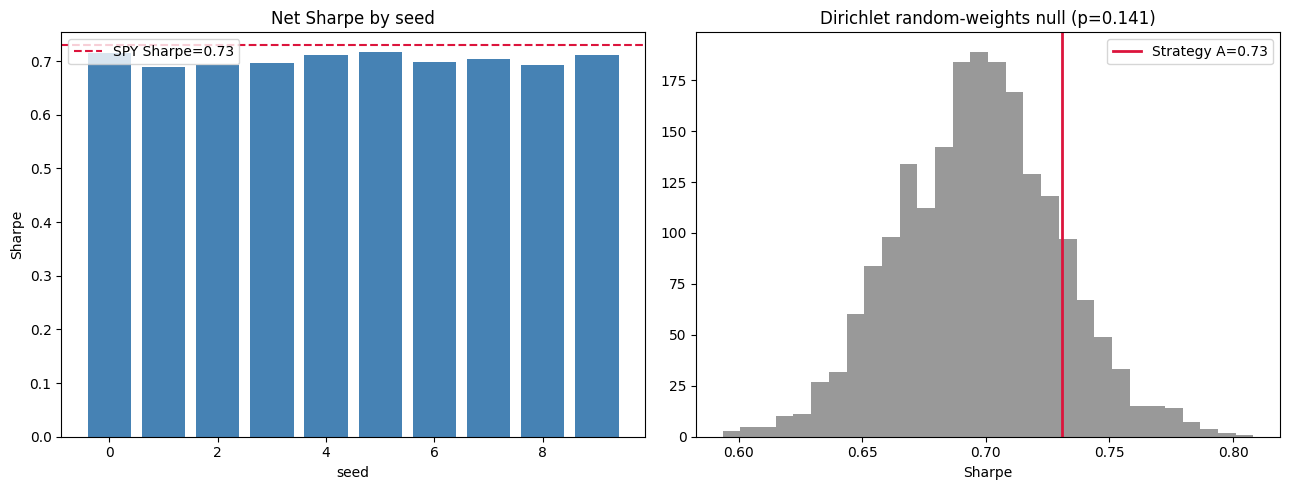

In [8]:
# Dirichlet null distribution (mirrors validation.dirichlet_null; verified against its p-value)
def _dirichlet_samples(features, walks, config, n_sims, seed):
    base = run_strategy_a(features, walks, config, seed)
    strat = compute_strategy_metrics(base['returns'])['sharpe']
    sched = base['weights'][['date','ticker']].merge(
        features[['date','ticker','fwd_ret_1m']], on=['date','ticker'], how='left')
    dates = list(sched['date'].unique())
    fwd_by_date = [sched.loc[sched['date'] == d, 'fwd_ret_1m'].to_numpy() for d in dates]
    rng = np.random.default_rng(seed); null = []
    for _ in range(n_sims):
        rr = []
        for fwd in fwd_by_date:
            w = project_to_simplex(np.log(rng.gamma(1.0, 1.0, len(fwd))),
                                   config['max_weight'], config['min_weight'])
            rr.append(float((w * fwd).sum()))
        null.append(compute_strategy_metrics(pd.Series(rr))['sharpe'])
    return strat, np.array(null)

strat_s, null_s = _dirichlet_samples(features, walks, CONFIG, n_sims=2000, seed=SEED)
assert abs(np.mean(null_s >= strat_s) - dn['p_value']) < 1e-9, 'viz null diverged from library'

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].bar(seed_df.seed, seed_df.sharpe_net, color='steelblue')
ax[0].axhline(sharpe_SPY, color='crimson', ls='--', label=f'SPY Sharpe={sharpe_SPY:.2f}')
ax[0].set_title('Net Sharpe by seed'); ax[0].set_xlabel('seed'); ax[0].set_ylabel('Sharpe'); ax[0].legend()
ax[1].hist(null_s, bins=30, color='gray', alpha=0.8)
ax[1].axvline(strat_s, color='crimson', lw=2, label=f'Strategy A={strat_s:.2f}')
ax[1].set_title(f"Dirichlet random-weights null (p={dn['p_value']:.3f})"); ax[1].set_xlabel('Sharpe'); ax[1].legend()
plt.tight_layout(); plt.show()


## 7. Pre-registered acceptance check
All six bars from `experiments/H_strategy_a.md` must hold for Strategy A to advance to rung 1.


In [9]:
bars = []
def bar(n, desc, passed, detail):
    bars.append((n, bool(passed)))
    print(f"  Bar {n}: {'PASS' if passed else 'FAIL'}  -  {desc}\n         {detail}")

print('Pre-registered acceptance bars (net of 5 bps):\n')
bar(1, 'OOS Sharpe(A) > Sharpe(SPY)', sharpe_A_net > sharpe_SPY,
    f'Sharpe(A,net)={sharpe_A_net:.3f} vs Sharpe(SPY)={sharpe_SPY:.3f}')
bar(2, 'max_drawdown(A) >= max_drawdown(SPY) (no deeper)', mdd_A >= mdd_SPY,
    f'MDD(A,net)={mdd_A:.3f} vs MDD(SPY)={mdd_SPY:.3f}')
bar(3, 'label-shuffle median Sharpe < Sharpe(A) (signal real)', np.median(shuffled) < sharpe_A_gross,
    f'shuffle median={np.median(shuffled):.3f} < Sharpe(A,gross)={sharpe_A_gross:.3f}')
bar(4, 'bootstrap 95% Sharpe CI lower bound > Sharpe(SPY)', ci['sharpe_lo'] > sharpe_SPY,
    f"CI_lo={ci['sharpe_lo']:.3f} vs Sharpe(SPY)={sharpe_SPY:.3f}")
bar(5, 'Dirichlet random-weights null p-value < 0.10', dn['p_value'] < 0.10,
    f"p={dn['p_value']:.4f} (strat={dn['strategy_sharpe']:.2f}, null_mean={dn['null_mean']:.2f})")
bar(6, 'min Sharpe across seeds 0-9 > Sharpe(SPY)', seed_df.sharpe_net.min() > sharpe_SPY,
    f'min seed Sharpe(net)={seed_df.sharpe_net.min():.3f} vs Sharpe(SPY)={sharpe_SPY:.3f}')

n_pass = sum(p for _, p in bars)
verdict = 'Strategy A ADVANCES to rung 1' if n_pass == 6 else 'Strategy A does NOT advance'
print('\n' + '=' * 64)
print(f'VERDICT: {n_pass}/6 bars passed  ->  {verdict}')
print('=' * 64)
if n_pass < 6:
    print('Failed bars:', [n for n, p in bars if not p])
    print('Per the pre-registration: record the failure and diagnose before any tuning.')
    print('No retroactive bar relaxation; changing the config after seeing test results')
    print('would invalidate the pre-registration (start a new H-file with a new search box).')


Pre-registered acceptance bars (net of 5 bps):

  Bar 1: FAIL  -  OOS Sharpe(A) > Sharpe(SPY)
         Sharpe(A,net)=0.715 vs Sharpe(SPY)=0.731
  Bar 2: PASS  -  max_drawdown(A) >= max_drawdown(SPY) (no deeper)
         MDD(A,net)=-0.495 vs MDD(SPY)=-0.508
  Bar 3: PASS  -  label-shuffle median Sharpe < Sharpe(A) (signal real)
         shuffle median=0.690 < Sharpe(A,gross)=0.731
  Bar 4: FAIL  -  bootstrap 95% Sharpe CI lower bound > Sharpe(SPY)
         CI_lo=0.197 vs Sharpe(SPY)=0.731
  Bar 5: FAIL  -  Dirichlet random-weights null p-value < 0.10
         p=0.1405 (strat=0.73, null_mean=0.70)
  Bar 6: FAIL  -  min Sharpe across seeds 0-9 > Sharpe(SPY)
         min seed Sharpe(net)=0.689 vs Sharpe(SPY)=0.731

VERDICT: 2/6 bars passed  ->  Strategy A does NOT advance
Failed bars: [1, 4, 5, 6]
Per the pre-registration: record the failure and diagnose before any tuning.
No retroactive bar relaxation; changing the config after seeing test results
would invalidate the pre-registration (st

## 8. Reading the verdict
The benchmark ladder ships complexity only when it earns its keep on this exact harness.
If Strategy A clears all six bars it becomes rung 1 — the bar Strategy B (MVO + Black-Litterman
with LSTM-forecast views) must then beat. If it does not, the honest outcome is recorded as-is:
the harness, the leakage/luck checks, and the pre-registered verdict are the deliverable, not a
guaranteed win. Any post-hoc change to the config is a new, separately pre-registered experiment.
